# Exploratory Data Analysis Starter

## Import packages

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Shows plots in jupyter notebook
%matplotlib inline

# Set plot style
sns.set(color_codes=True)

---

## Loading data with Pandas

We need to load `client_data.csv` and `price_data.csv` into individual dataframes so that we can work with them in Python. For this notebook and all further notebooks, it will be assumed that the CSV files will the placed in the same file location as the notebook. If they are not, please adjust the directory within the `read_csv` method accordingly.

In [2]:
#data_1 = 'https://raw.githubusercontent.com/Walter-Mokwena/Machine_learning_projects/main/power_co_customer_churn/client_data.csv'
#data_2 = 'https://raw.githubusercontent.com/Walter-Mokwena/Machine_learning_projects/main/power_co_customer_churn/price_data.csv'
#!wget $data_1


In [3]:
#!wget $data_2

In [4]:
client_df = pd.read_csv('client_data.csv.1')
price_df = pd.read_csv('price_data.csv.1')

You can view the first 3 rows of a dataframe using the `head` method. Similarly, if you wanted to see the last 3, you can use `tail(3)`

In [5]:
client_df.head(3).T

,0,1,2
id,24011ae4ebbe3035111d65fa7c15bc57,d29c2c54acc38ff3c0614d0a653813dd,764c75f661154dac3a6c254cd082ea7d
channel_sales,foosdfpfkusacimwkcsosbicdxkicaua,MISSING,foosdfpfkusacimwkcsosbicdxkicaua
cons_12m,0,4660,544
cons_gas_12m,54946,0,0
cons_last_month,0,0,0
date_activ,2013-06-15,2009-08-21,2010-04-16
date_end,2016-06-15,2016-08-30,2016-04-16
date_modif_prod,2015-11-01,2009-08-21,2010-04-16
date_renewal,2015-06-23,2015-08-31,2015-04-17
forecast_cons_12m,0.0,189.95,47.96


In [6]:
price_df.head(3)

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0


---

## Descriptive statistics of data

### Data types

It is useful to first understand the data that you're dealing with along with the data types of each column. The data types may dictate how you transform and engineer features.

To get an overview of the data types within a data frame, use the `info()` method.

In [7]:
client_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  str    
 1   channel_sales                   14606 non-null  str    
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  str    
 6   date_end                        14606 non-null  str    
 7   date_modif_prod                 14606 non-null  str    
 8   date_renewal                    14606 non-null  str    
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  float64
 12  forecast_meter_rent_12m         14606 non-n

In [8]:
price_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 193002 entries, 0 to 193001
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  193002 non-null  str    
 1   price_date          193002 non-null  str    
 2   price_off_peak_var  193002 non-null  float64
 3   price_peak_var      193002 non-null  float64
 4   price_mid_peak_var  193002 non-null  float64
 5   price_off_peak_fix  193002 non-null  float64
 6   price_peak_fix      193002 non-null  float64
 7   price_mid_peak_fix  193002 non-null  float64
dtypes: float64(6), str(2)
memory usage: 11.8 MB


### Statistics

Now let's look at some statistics about the datasets. We can do this by using the `describe()` method.

In [9]:
client_df.describe().round(2)

,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,pow_max,churn
count,14606.00,14606.00,14606.00,14606.00,14606.00,14606.00,14606.00,14606.00,14606.00,14606.00,14606.00,14606.00,14606.00,14606.00,14606.00,14606.00,14606.00,14606.0
mean,159220.29,28092.38,16090.27,1868.61,1399.76,0.97,63.09,0.14,0.05,43.13,152.79,24.57,24.56,1.29,189.26,5.00,18.14,0.1
std,573465.26,162973.06,64364.20,2387.57,3247.79,5.11,66.17,0.02,0.05,4.49,341.37,20.23,20.23,0.71,311.80,1.61,13.53,0.3
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,3.30,0.0
25%,5674.75,0.00,0.00,495.00,0.00,0.00,16.18,0.12,0.00,40.61,0.00,14.28,14.28,1.00,50.71,4.00,12.50,0.0
50%,14115.50,0.00,792.50,1112.88,314.00,0.00,18.80,0.14,0.08,44.31,37.39,21.64,21.64,1.00,112.53,5.00,13.86,0.0
75%,40763.75,0.00,3383.00,2401.79,1745.75,0.00,131.03,0.15,0.10,44.31,193.98,29.88,29.88,1.00,243.10,6.00,19.17,0.0
max,6207104.00,4154590.00,771203.00,82902.83,175375.00,30.00,599.31,0.27,0.20,59.27,15042.79,374.64,374.64,32.00,24570.65,13.00,320.00,1.0


In [10]:
price_df.describe().round(2)

,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
count,193002.00,193002.00,193002.00,193002.00,193002.00,193002.00
mean,0.14,0.05,0.03,43.33,10.62,6.41
std,0.03,0.05,0.04,5.41,12.84,7.77
min,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.13,0.00,0.00,40.73,0.00,0.00
50%,0.15,0.09,0.00,44.27,0.00,0.00
75%,0.15,0.10,0.07,44.44,24.34,16.23
max,0.28,0.23,0.11,59.44,36.49,17.46


---

## Data visualization

If you're working in Python, two of the most popular packages for visualization are `matplotlib` and `seaborn`. We highly recommend you use these, or at least be familiar with them because they are ubiquitous!

Below are some functions that you can use to get started with visualizations. 

In [11]:
def plot_stacked_bars(dataframe, title_, size_=(18, 10), rot_=0, legend_="upper right"):
    """
    Plot stacked bars with annotations
    """
    ax = dataframe.plot(
        kind="bar",
        stacked=True,
        figsize=size_,
        rot=rot_,
        title=title_
    )

    # Annotate bars
    annotate_stacked_bars(ax, textsize=14)
    # Rename legend
    plt.legend(["Retention", "Churn"], loc=legend_)
    # Labels
    plt.ylabel("Company base (%)")
    plt.show()

def annotate_stacked_bars(ax, pad=0.99, colour="white", textsize=13):
    """
    Add value annotations to the bars
    """

    # Iterate over the plotted rectanges/bars
    for p in ax.patches:
        
        # Calculate annotation
        value = str(round(p.get_height(),1))
        # If value is 0 do not annotate
        if value == '0.0':
            continue
        ax.annotate(
            value,
            ((p.get_x()+ p.get_width()/2)*pad-0.05, (p.get_y()+p.get_height()/2)*pad),
            color=colour,
            size=textsize
        )

def plot_distribution(dataframe, column, ax, bins_=50):
    """
    Plot variable distirbution in a stacked histogram of churned or retained company
    """
    # Create a temporal dataframe with the data to be plot
    temp = pd.DataFrame({"Retention": dataframe[dataframe["churn"]==0][column],
    "Churn":dataframe[dataframe["churn"]==1][column]})
    # Plot the histogram
    temp[["Retention","Churn"]].plot(kind='hist', bins=bins_, ax=ax, stacked=True)
    # X-axis label
    ax.set_xlabel(column)
    # Change the x-axis to plain style
    ax.ticklabel_format(style='plain', axis='x')

Thhe first function `plot_stacked_bars` is used to plot a stacked bar chart. An example of how you could use this is shown below:

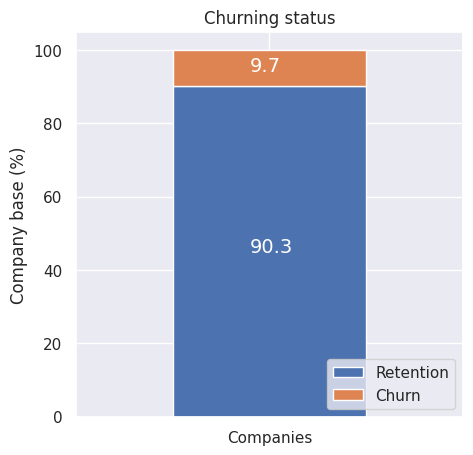

In [12]:
churn = client_df[['id', 'churn']]
churn.columns = ['Companies', 'churn']
churn_total = churn.groupby(churn['churn']).count()
churn_percentage = churn_total / churn_total.sum() * 100
plot_stacked_bars(churn_percentage.transpose(), "Churning status", (5, 5), legend_="lower right")

The second function `annotate_bars` is used by the first function, but the third function `plot_distribution` helps you to plot the distribution of a numeric column. An example of how it can be used is given below:

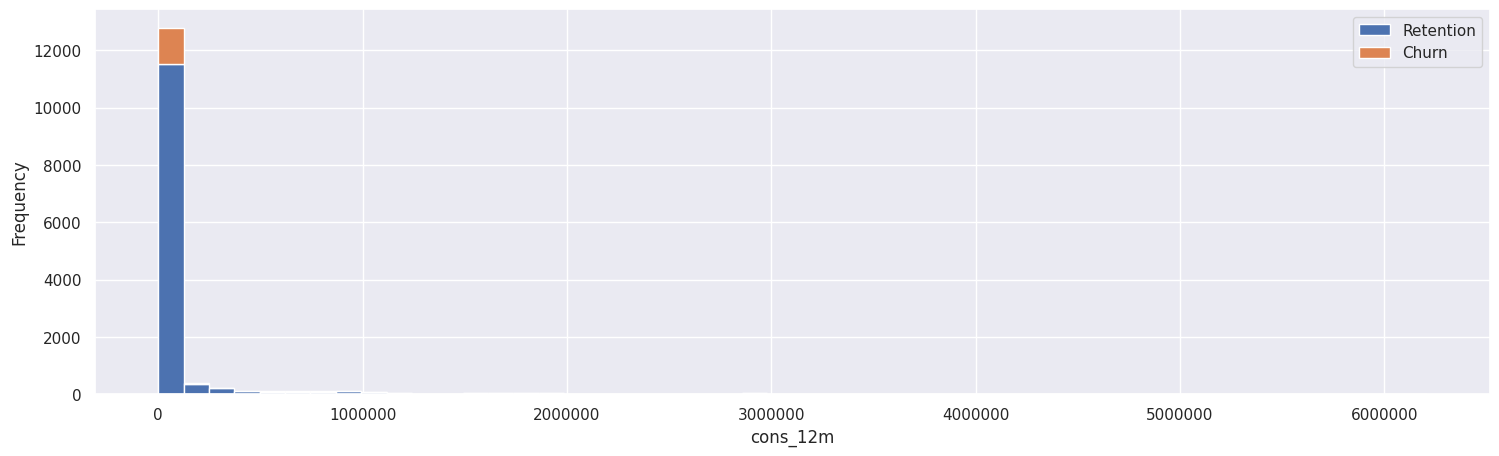

In [13]:
consumption = client_df[['id', 'cons_12m', 'cons_gas_12m', 'cons_last_month', 'imp_cons', 'has_gas', 'churn']]

fig, axs = plt.subplots(nrows=1, figsize=(18, 5))

plot_distribution(consumption, 'cons_12m', axs)

In [14]:
client_numericals = list(client_df.dtypes[(client_df.dtypes == 'float') | (client_df.dtypes == 'int')].index)

### numerical columns distributions
- When it comes to gas and electricity what i am observing is that powerco has majority of its clients clusterd around a certain demand and a few clients with very large gas and electricity demand. Making the dataset to be very right skewed.

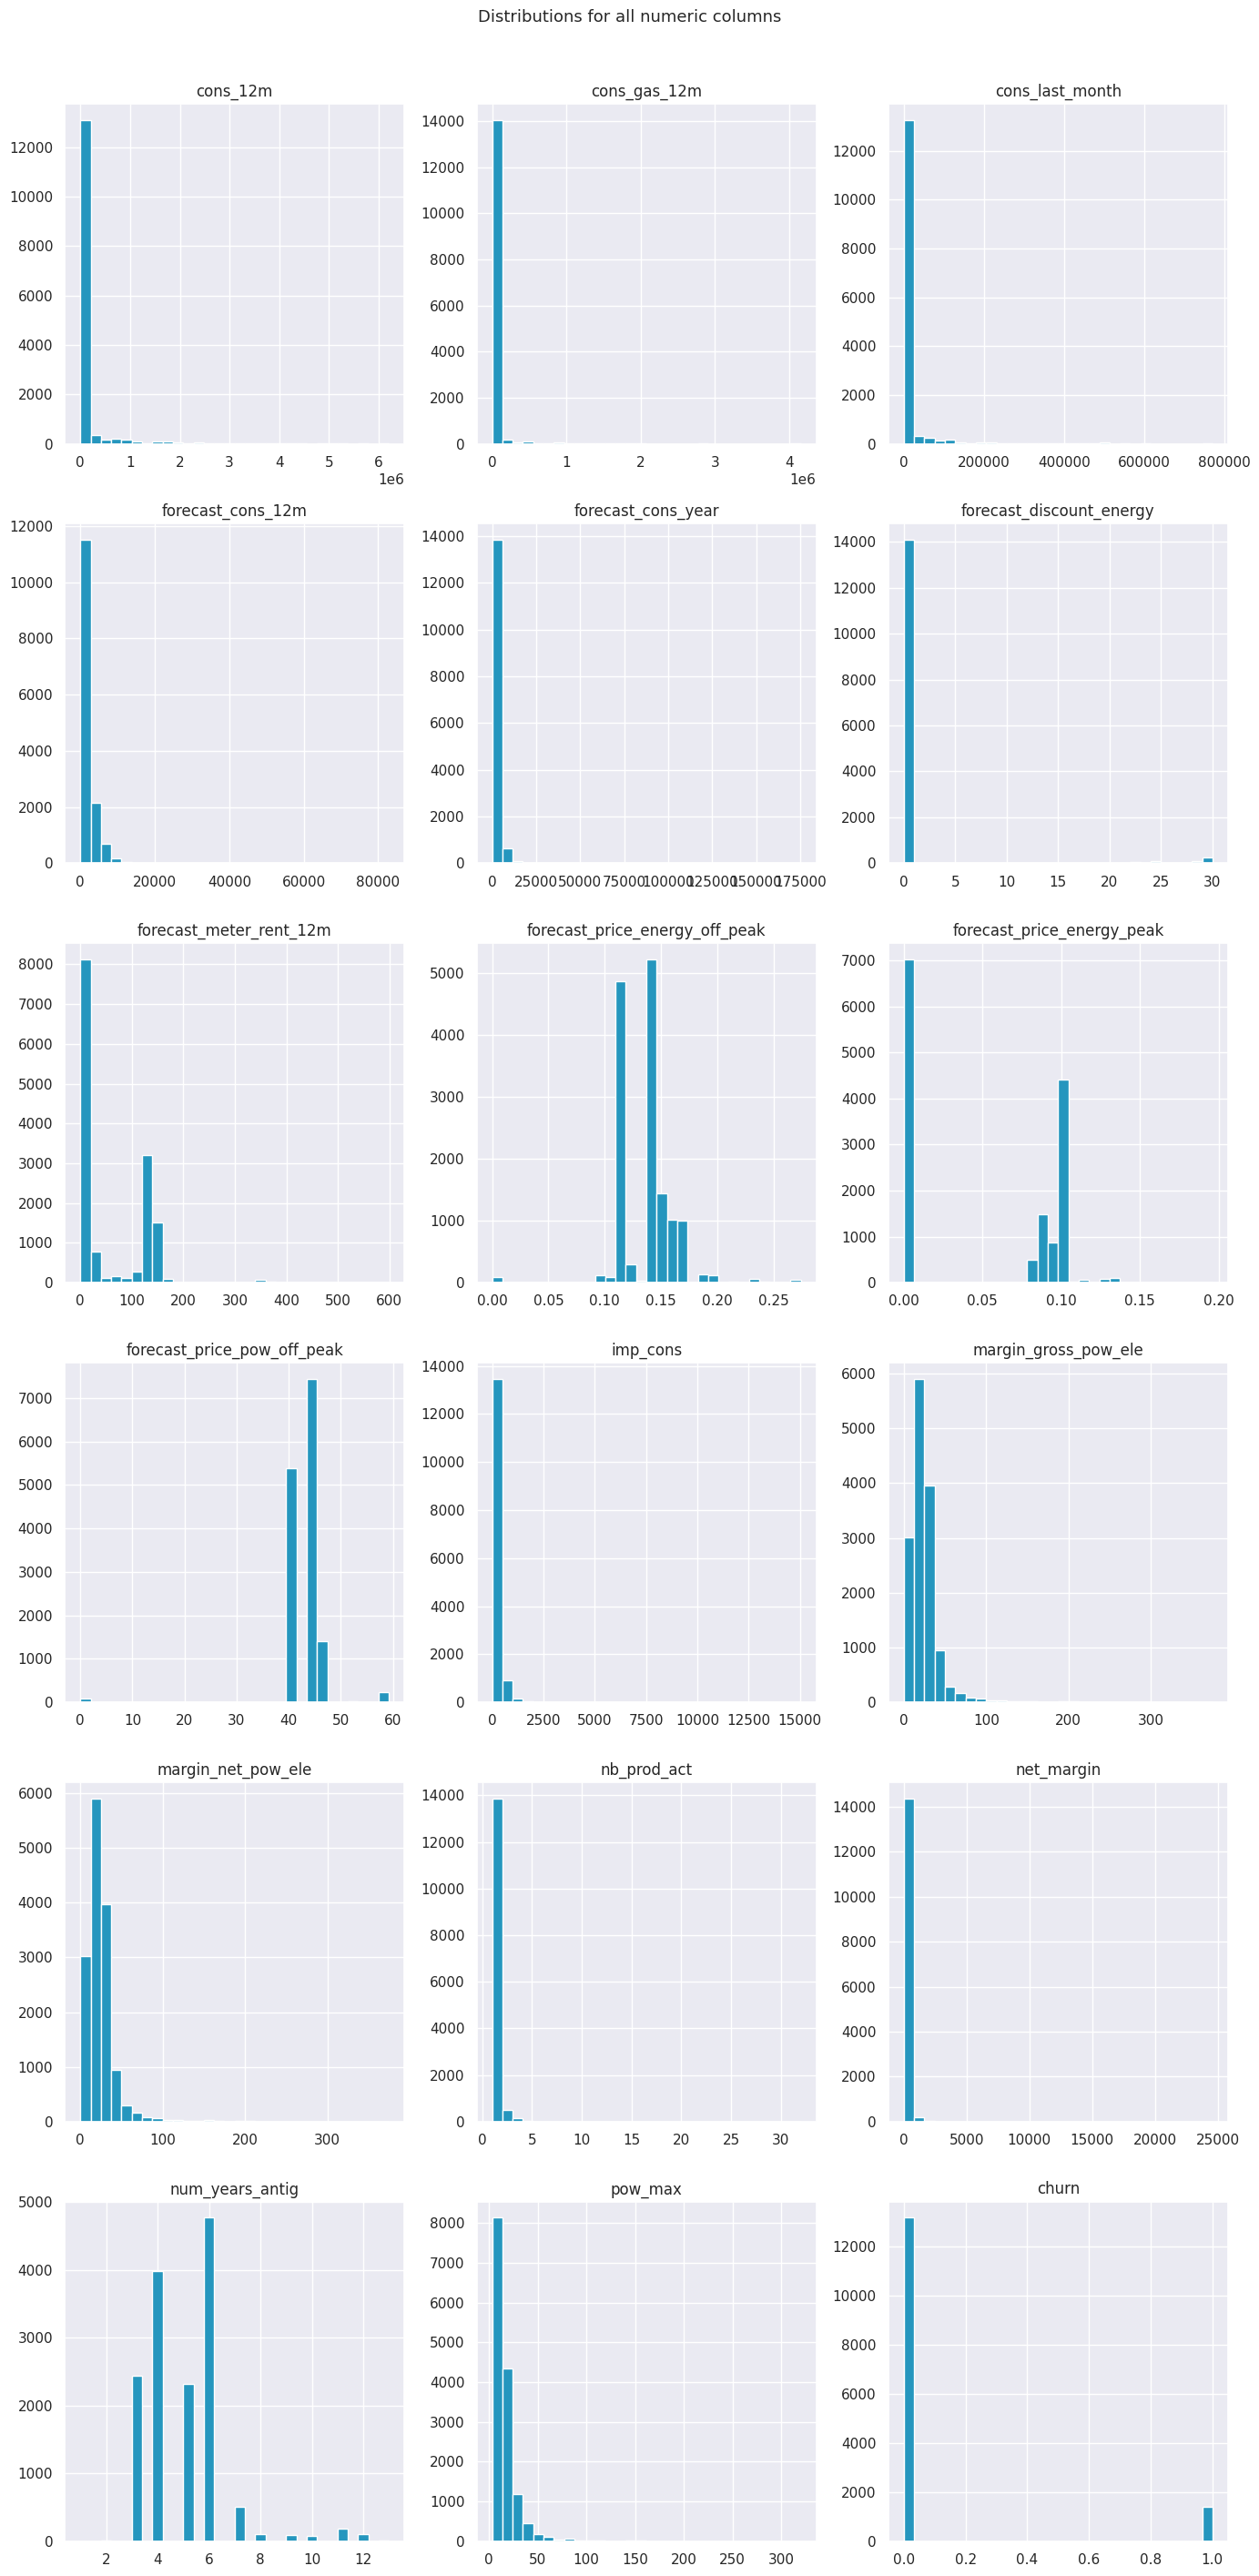

In [15]:
fig, axes = plt.subplots(6, 3, figsize=(14, 28))
for ax, col in zip(axes.flatten(), client_numericals):
    client_df[col].hist(ax=ax, bins=30, color='#2596be', edgecolor='white')
    ax.set_title(col)
fig.suptitle('Distributions for all numeric columns', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

In [16]:
from IPython.display import display
for col in client_numericals:
    df_summary = client_df.groupby('churn')[col].agg(['mean', 'median', 'std'])
    print(col)
    display(df_summary)

cons_12m


,mean,median,std
churn,,,
0,167867.266550,14075.0,596815.827246
1,78862.478506,14529.0,260433.325508


cons_gas_12m


,mean,median,std
churn,,,
0,30121.497308,0.0,170618.334766
1,9235.411557,0.0,49685.387987


cons_last_month


...

,mean,median,std
churn,,,
0,5.037006,5.0,1.615279
1,4.633545,4.0,1.531853


pow_max


,mean,median,std
churn,,,
0,18.000339,13.856,13.154277
1,19.387827,13.856,16.613367


churn


,mean,median,std
churn,,,
0,0.0,0.0,0.0
1,1.0,1.0,0.0


In [17]:
# pd.crosstab counts how many times each combination of values appears
ct_pct = pd.crosstab(client_df['has_gas'], client_df['churn'], normalize='index').round(2) * 100
ct_pct

churn,0,1
has_gas,,
f,90.0,10.0
t,92.0,8.0


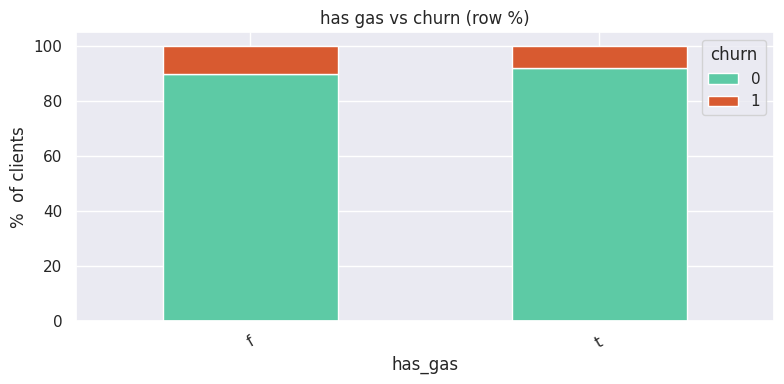

In [18]:
#plotting the cross tab
ct_pct.plot(kind='bar', stacked=True, figsize=(8, 4), color=['#5DCAA5', "#D85A30", "#7F77DD"], edgecolor='white')
plt.title('has gas vs churn (row %)')
plt.xlabel('has_gas')
plt.ylabel('%  of clients')
plt.xticks(rotation=30)
plt.legend(title='churn')
plt.tight_layout()
plt.show()

In [19]:
client_numericals.pop()
client_numericals

['cons_12m',
 'cons_gas_12m',
 'cons_last_month',
 'forecast_cons_12m',
 'forecast_cons_year',
 'forecast_discount_energy',
 'forecast_meter_rent_12m',
 'forecast_price_energy_off_peak',
 'forecast_price_energy_peak',
 'forecast_price_pow_off_peak',
 'imp_cons',
 'margin_gross_pow_ele',
 'margin_net_pow_ele',
 'nb_prod_act',
 'net_margin',
 'num_years_antig',
 'pow_max']

### insights after log transformation
- the mean difference between churned and non churned clients disapeared. This shows that consumption alone is not a good predictor of churn
- the amount of energy used by a client does tell us much about weather a client will stay or leave

In [20]:
for col in client_numericals:
    client_df[col] = np.log1p(client_df[col])

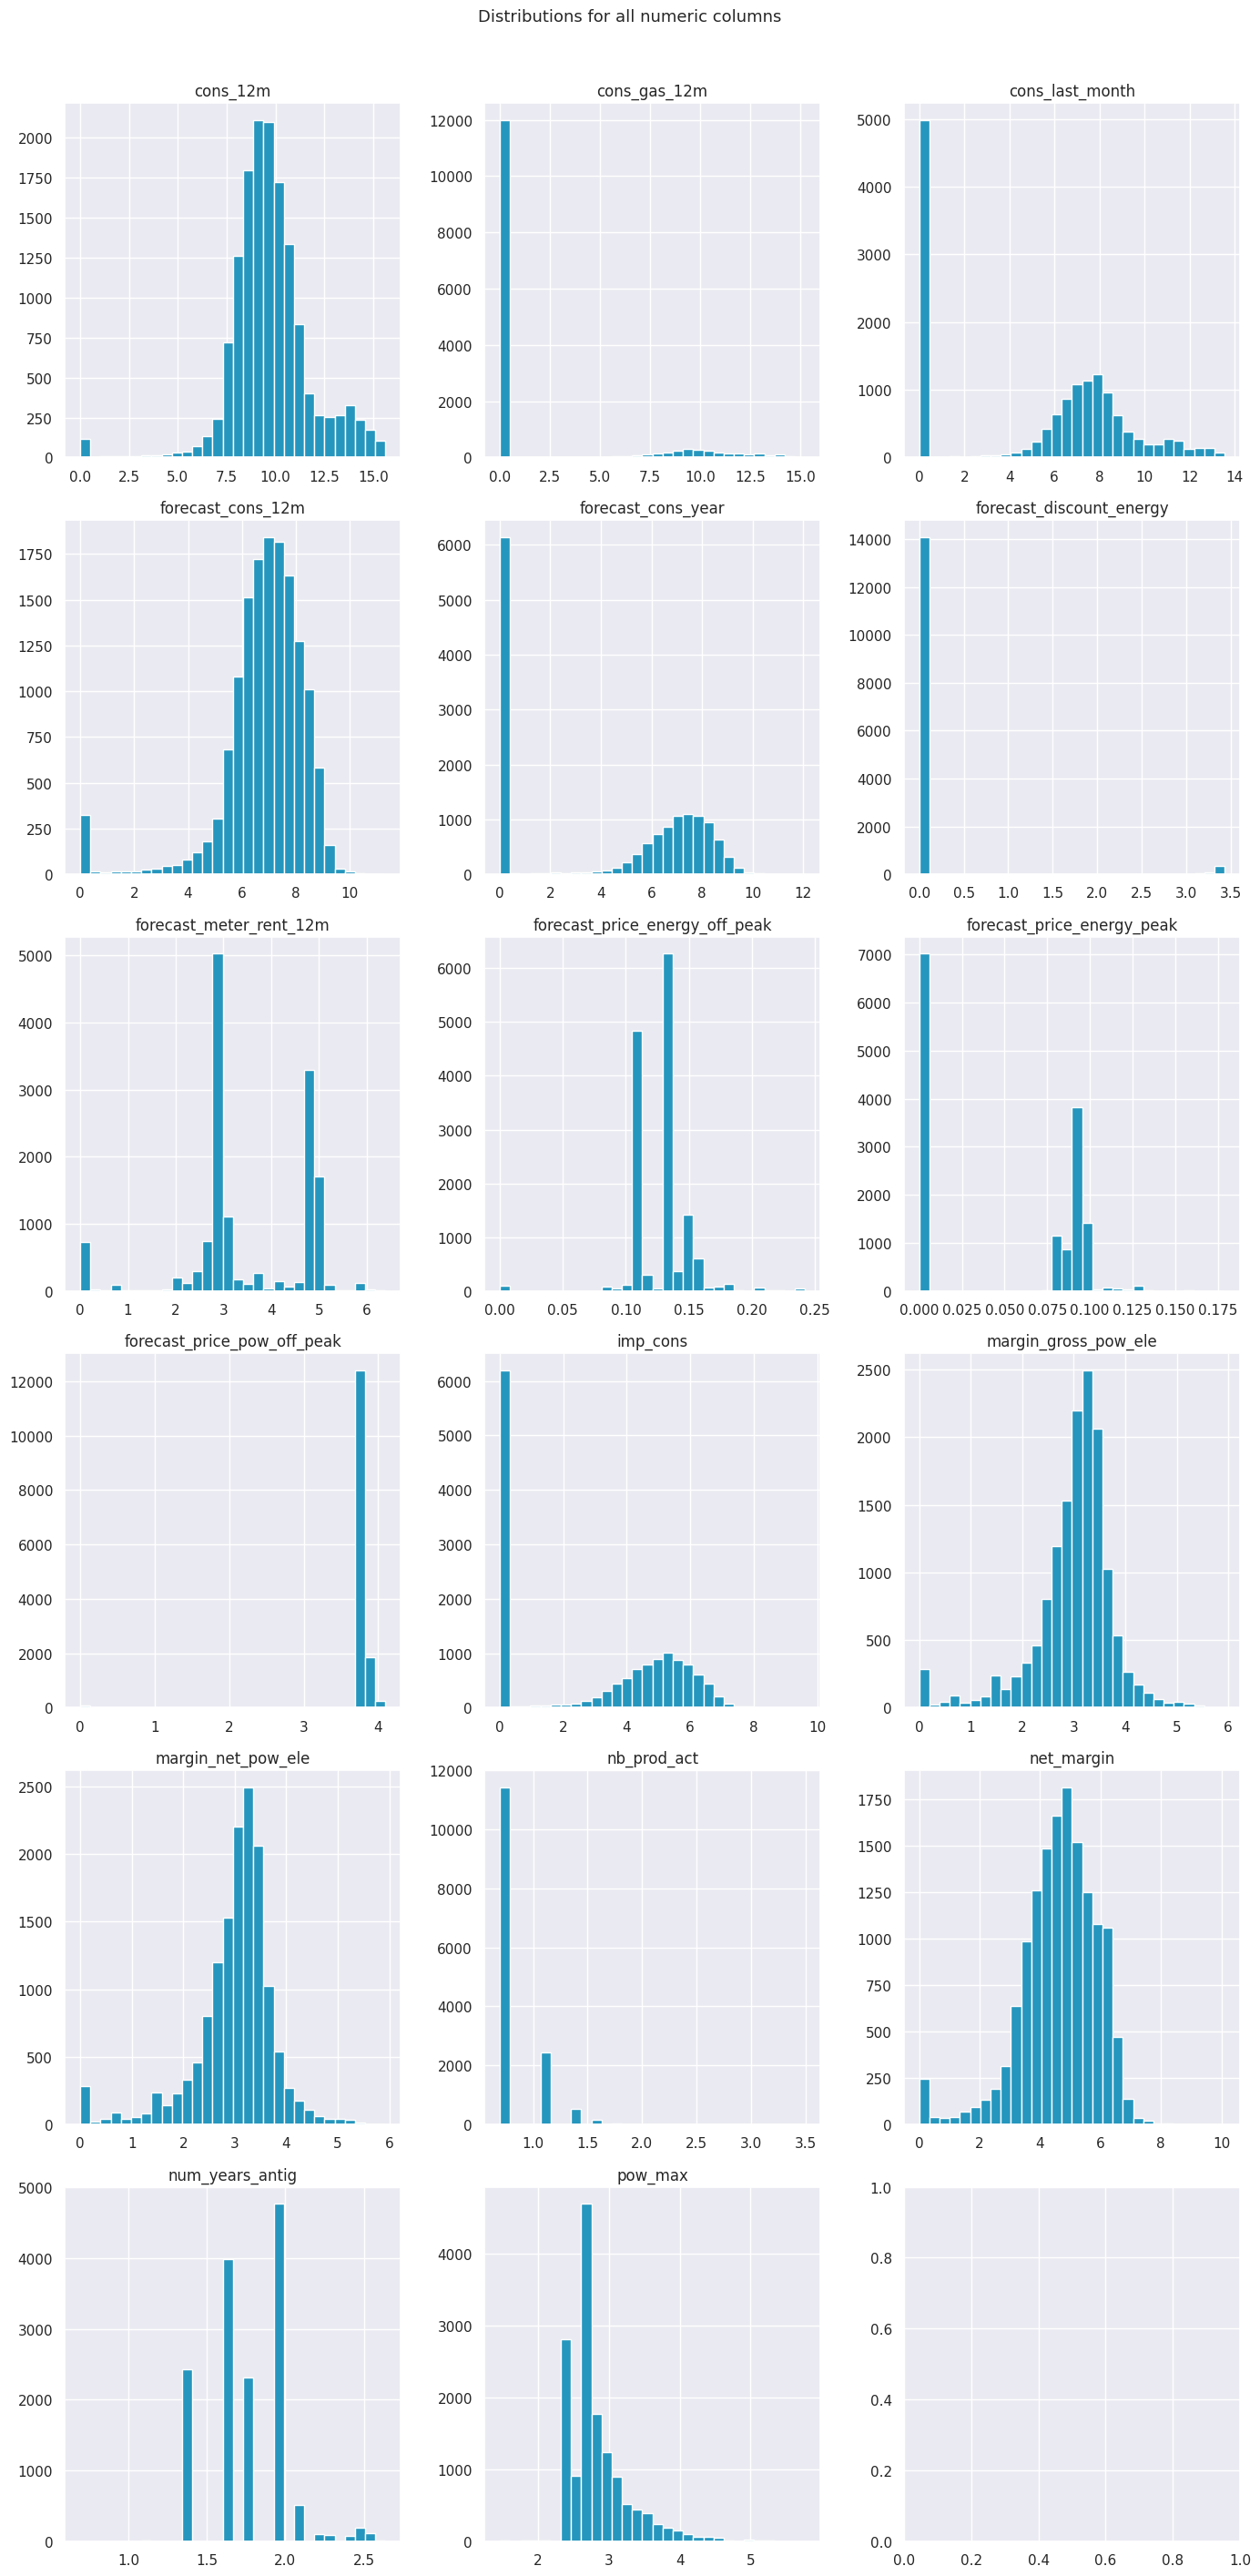

In [21]:
fig, axes = plt.subplots(6, 3, figsize=(14, 28))
for ax, col in zip(axes.flatten(), client_numericals):
    client_df[col].hist(ax=ax, bins=30, color='#2596be', edgecolor='white')
    ax.set_title(col)
fig.suptitle('Distributions for all numeric columns', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

In [22]:
for col in client_numericals:
    df_summary = client_df.groupby('churn')[col].agg(['mean', 'median', 'std'])
    print(col)
    display(df_summary)

cons_12m


,mean,median,std
churn,,,
0,9.737131,9.552226,2.055786
1,9.622340,9.583971,1.847063


cons_gas_12m


,mean,median,std
churn,,,
0,1.826873,0.0,3.993301
1,1.491348,0.0,3.551738


cons_last_month


...

,mean,median,std
churn,,,
0,4.620618,4.726148,1.265078
1,4.698790,4.811045,1.319639


num_years_antig


,mean,median,std
churn,,,
0,1.765754,1.791759,0.249631
1,1.696932,1.609438,0.245700


pow_max


,mean,median,std
churn,,,
0,2.830365,2.698404,0.415856
1,2.879591,2.698404,0.447121


# Exploratory data analysis for price

In [27]:
price_numericals = ['price_off_peak_var', 'price_peak_var',
       'price_mid_peak_var', 'price_off_peak_fix', 'price_peak_fix',
       'price_mid_peak_fix']

In [33]:
price_df.head()

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0
3,038af19179925da21a25619c5a24b745,2015-04-01,0.149626,0.0,0.0,44.266931,0.0,0.0
4,038af19179925da21a25619c5a24b745,2015-05-01,0.149626,0.0,0.0,44.266931,0.0,0.0


In [34]:
price_df.describe()

,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
count,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000
mean,0.141027,0.054630,0.030496,43.334477,10.622875,6.409984
std,0.025032,0.049924,0.036298,5.410297,12.841895,7.773592
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.125976,0.000000,0.000000,40.728885,0.000000,0.000000
50%,0.146033,0.085483,0.000000,44.266930,0.000000,0.000000
75%,0.151635,0.101673,0.072558,44.444710,24.339581,16.226389
max,0.280700,0.229788,0.114102,59.444710,36.490692,17.458221


### 1. understand the temporal structure
- 12 months of history exist for every client
- The price data is from every month of the year 2015

In [38]:
price_df['price_date'] = pd.to_datetime(price_df['price_date'])
price_df['price_date'].min()

Timestamp('2015-12-01 00:00:00')

In [39]:
price_df['price_date'].max()

Timestamp('2015-12-01 00:00:00')

In [40]:
price_df['price_date'].nunique()

12

In [42]:
price_df.groupby('id')['price_date'].count()

id
0002203ffbb812588b632b9e628cc38d    12
0004351ebdd665e6ee664792efc4fd13    12
0010bcc39e42b3c2131ed2ce55246e3c    12
0010ee3855fdea87602a5b7aba8e42de    12
00114d74e963e47177db89bc70108537    12
                                    ..
ffef185810e44254c3a4c6395e6b4d8a    12
fffac626da707b1b5ab11e8431a4d0a2    12
fffc0cacd305dd51f316424bbb08d1bd    12
fffe4f5646aa39c7f97f95ae2679ce64    12
ffff7fa066f1fb305ae285bb03bf325a    12
Name: price_date, Length: 16096, dtype: int64

### 2. Distributions of all price columns
- price_of_peak_var is almost normally distributed with clients paying 0.14 on average
- During peak hours the are a lot of clients not paying anything, meaning they do not consume electricity during this period. and a lot of clients around ~0.10 (bimodal distribution)
- During mid peak hours the trend is similar to peak hours with a lot of clients that have zero mid peak prices and a group of clients clustered between 0.06 and 0.08
- The price_peak_fix is unimodal meaning all clients pay this charge.
- price_peak_fix and price_mid_peak_fix are bimodal with majority of clients that are zero paying and clients that pay 25 and 16 respectively. meaning that there are clients are separated into to tiers, Those who only pay when they consume during these hours and those who pay for peak and mid-peak access irregardless of consumption
- Since there are clients from different pricing achitectures. i will further investigate weather these differences has an influence on weather a client

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


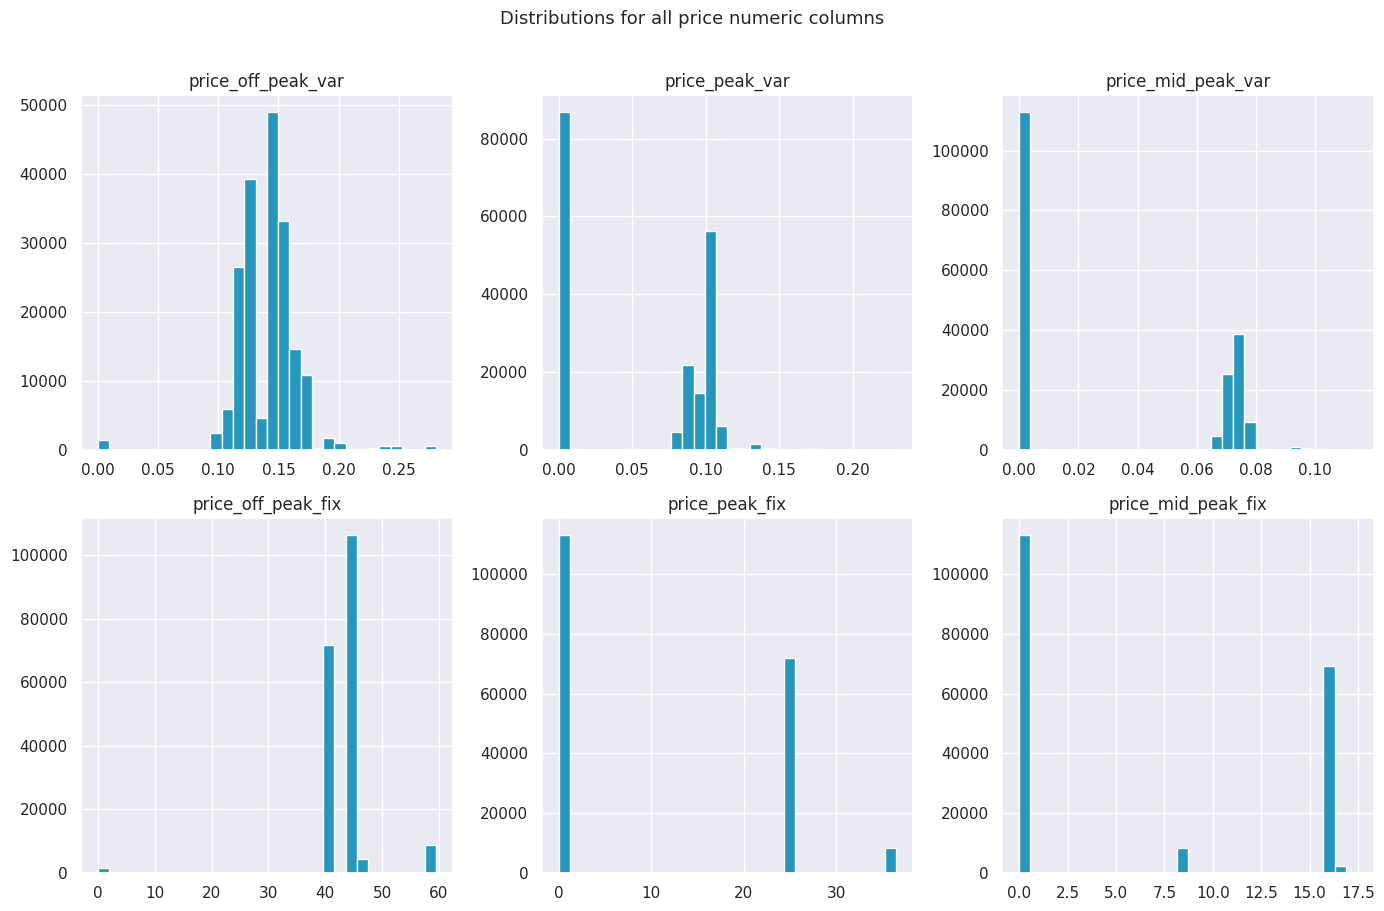

In [43]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, col in zip(axes.flatten(), price_numericals):
    price_df[col].hist(ax=ax, bins=30, color='#2596be', edgecolor='white')
    ax.set_title(col)
fig.suptitle('Distributions for all price numeric columns', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

In [44]:
price_df['has_peak_var'] = (price_df['price_peak_var'] > 0).astype(int)

In [45]:
price_df.head()

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix,has_peak_var
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0,0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0,0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0,0
3,038af19179925da21a25619c5a24b745,2015-04-01,0.149626,0.0,0.0,44.266931,0.0,0.0,0
4,038af19179925da21a25619c5a24b745,2015-05-01,0.149626,0.0,0.0,44.266931,0.0,0.0,0
